# Beaderstadt Titanic Dataset: Classification Machine Learning Models

**Author:** Alissa Beaderstadt<br>
**Date:** November 3, 2025<br>

## Introduction
In this project, I’ll extend my previous Titanic dataset exploration to include classification models: Decision Tree, Support Vector Machine (SVM), and Neural Network. Then I'll evaluate model performance across three feature sets (Base, Raise the Bar, Lower the Bar).

## Imports
Import the necessary Python libraries for this notebook.  

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import ListedColormap
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score


## Section 1. Import the Data

### 1.1 Load the Titanic Dataset
The Titanic dataset is built into `Seaborn`, so we can easily load it without needing to import an external file. We don't need a detailed inspection of the data as we've done that previously and are familiar.

In [28]:
# Load Titanic dataset
titanic = sns.load_dataset('titanic')

# Display just a few records to verify
print(titanic.head(10))

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

## Section 2. Data Exploration and Preparation
### 2.1 Handle Missing Values and Clean Data




In [29]:
# Fill missing
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embark_town'] = titanic['embark_town'].fillna(titanic['embark_town'].mode()[0])


### 2.2 Feature Engineering
Create any new features that might be helpful for the model from the existing data. This is providing existing data in a more helpful, concise way for modeling.

In this case, we want to add a calculated feature we'll call family_size.

In [30]:
# Create new feature
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# Map categories to numeric values
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})
titanic['alone'] = titanic['alone'].astype(int)

## Section 3. Feature Selection and Justification
### 3.1 Choose features and target
**Target:**
- Always survived (0 = did not survive, 1 = survived).<br>
**Feature Cases:**
1. **Case 1: Single feature** - `alone`
    - Why: Being alone might affect survival; family or groups may have influenced who got rescued first.
2. **Case 2: Single feature** - `age`
    - Why: Age is historically important; children often had higher survival rates.
3. **Case 3: Two features** - `age` + `family_size`
    - Why: Combining age with family size may capture survival patterns better; families traveling together might have increased or decreased chances.


### 3.2 Define X (features) and y (target)
- Assign input features to X a pandas DataFrame with 1 or more input features
- Assign target variable to y (as applicable) - a pandas Series with a single target feature
- Again - use comments to run a single case at a time
- The follow starts with only the statements needed for case 1. 
- Double brackets [[ ]]  makes a 2D DataFrame
- Single brackets [ ]  make a 1D Series

In [31]:
# -----------------------------
# Case 1: Feature = alone
# -----------------------------
# Select the feature 'alone' as input (2D DataFrame)
X1 = titanic[['alone']]

# Select 'survived' as the target (1D Series)
y1 = titanic['survived']


# -----------------------------
# Case 2: Feature = age
# -----------------------------
# Select the feature 'age' and drop rows with missing values
X2 = titanic[['age']].dropna()

# Select matching 'survived' values using the same indices
y2 = titanic.loc[X2.index, 'survived']


# -----------------------------
# Case 3: Features = age + family_size
# -----------------------------
# Select both 'age' and 'family_size', drop rows with missing values
X3 = titanic[['age', 'family_size']].dropna()

# Select corresponding 'survived' values
y3 = titanic.loc[X3.index, 'survived']


**Reflection 3:** 

1. Why are these features selected?
   - `alone`: An indicator of whether the passenger had family.
   - `age`: Survival may depend on age (children and women may have survived more).
   - `family_size`: Captures whether traveling in a group influences survival.
   - Combining features (age + family_size) may uncover interactions that single features can’t capture.

2. Which features are likely highly predictive?
   - `alone` may be predictive because social/family structures mattered.
   - `age` is often predictive because children and women may have survived more.
   - `family_size` could affect survival if families stayed together or helped each other.



## Section 4. Train a Classification Model (Decision Tree) <br>
Split the data, train decision tree models for three feature cases, evaluate performance, and visualize results.
### 4.1 Split the Data
We’ll use StratifiedShuffleSplit to maintain the same proportion of survivors in training and test sets.

In [32]:
# -----------------------------
# Case 1: Feature = alone
# -----------------------------
splitter1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
for train_idx1, test_idx1 in splitter1.split(X1, y1):
    X1_train = X1.iloc[train_idx1]
    X1_test  = X1.iloc[test_idx1]
    y1_train = y1.iloc[train_idx1]
    y1_test  = y1.iloc[test_idx1]

print('Case 1 - Alone:')
print('Train size:', len(X1_train), '| Test size:', len(X1_test))


# -----------------------------
# Case 2: Feature = age
# -----------------------------
splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
for train_idx2, test_idx2 in splitter2.split(X2, y2):
    X2_train = X2.iloc[train_idx2]
    X2_test  = X2.iloc[test_idx2]
    y2_train = y2.iloc[train_idx2]
    y2_test  = y2.iloc[test_idx2]

print('Case 2 - Age:')
print('Train size:', len(X2_train), '| Test size:', len(X2_test))


# -----------------------------
# Case 3: Features = age + family_size
# -----------------------------
splitter3 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
for train_idx3, test_idx3 in splitter3.split(X3, y3):
    X3_train = X3.iloc[train_idx3]
    X3_test  = X3.iloc[test_idx3]
    y3_train = y3.iloc[train_idx3]
    y3_test  = y3.iloc[test_idx3]

print('Case 3 - Age + Family Size:')
print('Train size:', len(X3_train), '| Test size:', len(X3_test))


Case 1 - Alone:
Train size: 712 | Test size: 179
Case 2 - Age:
Train size: 712 | Test size: 179
Case 3 - Age + Family Size:
Train size: 712 | Test size: 179


### 4.2 Create and Train Model (Decision Tree)
Create and train a decision tree model with no random initializer argument.

In [33]:
# -----------------------------
# CASE 1: Decision Tree using alone
# -----------------------------
tree_model1 = DecisionTreeClassifier()
tree_model1.fit(X1_train, y1_train)

# -----------------------------
# CASE 2: Decision Tree using age
# -----------------------------
tree_model2 = DecisionTreeClassifier()
tree_model2.fit(X2_train, y2_train)

# -----------------------------
# CASE 3: Decision Tree using age and family_size
# -----------------------------
tree_model3 = DecisionTreeClassifier()
tree_model3.fit(X3_train, y3_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 4.3 Predict and Evaluate Model Performance
Evaluate model performance on training data.

In [34]:
# -----------------------------
# Case 1: Predictions and Evaluation
# -----------------------------
y1_pred = tree_model1.predict(X1_train)
print("Decision Tree Training Results - Case 1 (Alone):")
print(classification_report(y1_train, y1_pred))

y1_test_pred = tree_model1.predict(X1_test)
print("Decision Tree Test Results - Case 1 (Alone):")
print(classification_report(y1_test, y1_test_pred))


# -----------------------------
# Case 2: Predictions and Evaluation
# -----------------------------
y2_pred = tree_model2.predict(X2_train)
print("Decision Tree Training Results - Case 2 (Age):")
print(classification_report(y2_train, y2_pred))

y2_test_pred = tree_model2.predict(X2_test)
print("Decision Tree Test Results - Case 2 (Age):")
print(classification_report(y2_test, y2_test_pred))


# -----------------------------
# Case 3: Predictions and Evaluation
# -----------------------------
y3_pred = tree_model3.predict(X3_train)
print("Decision Tree Training Results - Case 3 (Age + Family Size):")
print(classification_report(y3_train, y3_pred))

y3_test_pred = tree_model3.predict(X3_test)
print("Decision Tree Test Results - Case 3 (Age + Family Size):")
print(classification_report(y3_test, y3_test_pred))


Decision Tree Training Results - Case 1 (Alone):
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       439
           1       0.50      0.51      0.51       273

    accuracy                           0.62       712
   macro avg       0.60      0.60      0.60       712
weighted avg       0.62      0.62      0.62       712

Decision Tree Test Results - Case 1 (Alone):
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       110
           1       0.51      0.58      0.54        69

    accuracy                           0.63       179
   macro avg       0.61      0.62      0.61       179
weighted avg       0.64      0.63      0.63       179

Decision Tree Training Results - Case 2 (Age):
              precision    recall  f1-score   support

           0       0.68      0.92      0.78       439
           1       0.69      0.29      0.41       273

    accuracy                           0.

### 4.4 Report Confusion Matrix (as a heatmap)
Plot a confusion matrix as a heatmap for all three cases.

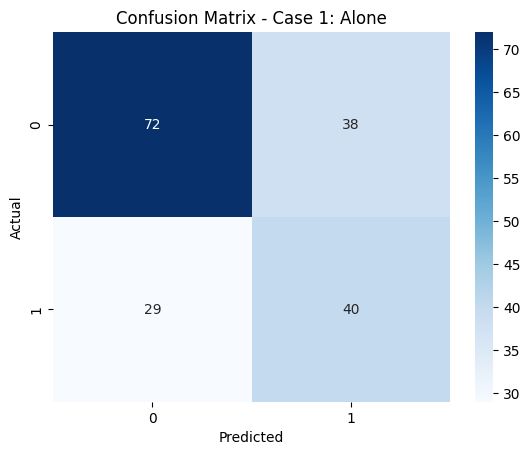

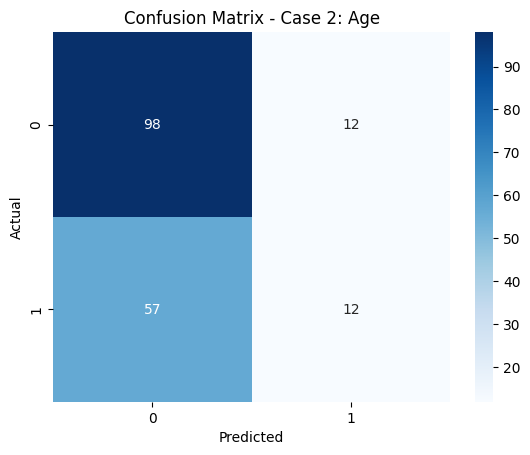

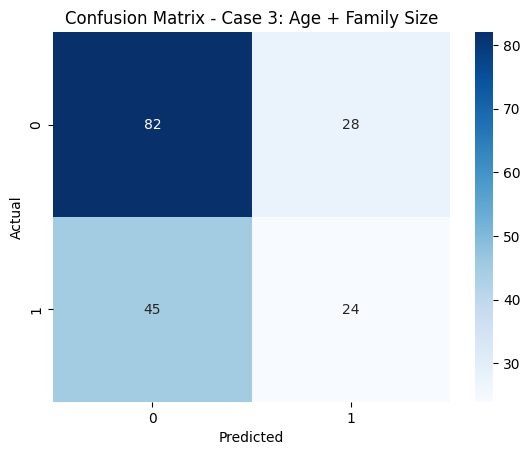

In [35]:
# -----------------------------
# Case 1
# -----------------------------
cm1 = confusion_matrix(y1_test, y1_test_pred)
sns.heatmap(cm1, annot=True, cmap='Blues')
plt.title('Confusion Matrix - Case 1: Alone')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# -----------------------------
# Case 2
# -----------------------------
cm2 = confusion_matrix(y2_test, y2_test_pred)
sns.heatmap(cm2, annot=True, cmap='Blues')
plt.title('Confusion Matrix - Case 2: Age')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# -----------------------------
# Case 3
# -----------------------------
cm3 = confusion_matrix(y3_test, y3_test_pred)
sns.heatmap(cm3, annot=True, cmap='Blues')
plt.title('Confusion Matrix - Case 3: Age + Family Size')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 4.5 Report Decision Tree Plot
Plot the decision tree model for each case. We give the plotter the names of the features and the names of the categories for the target. 

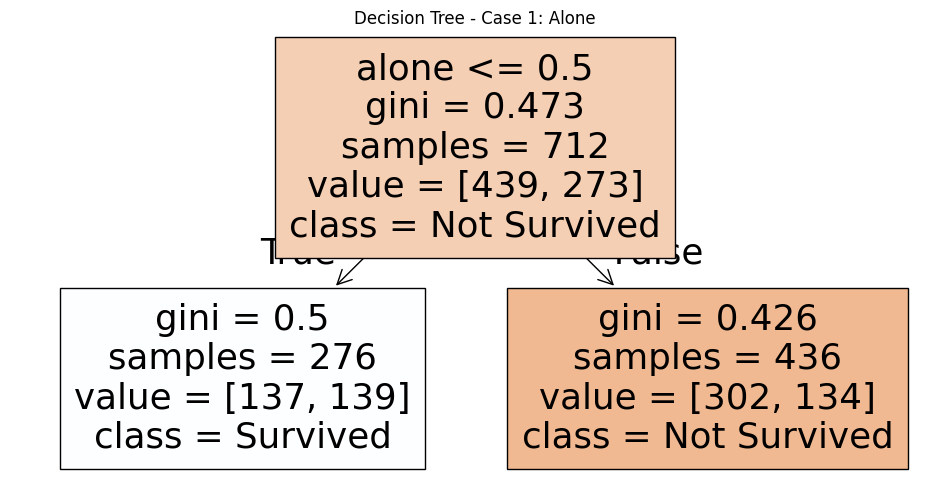

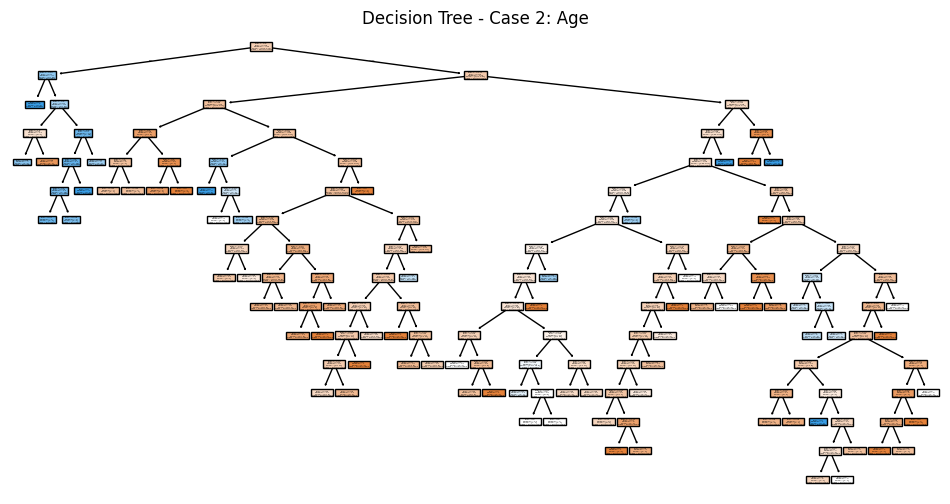

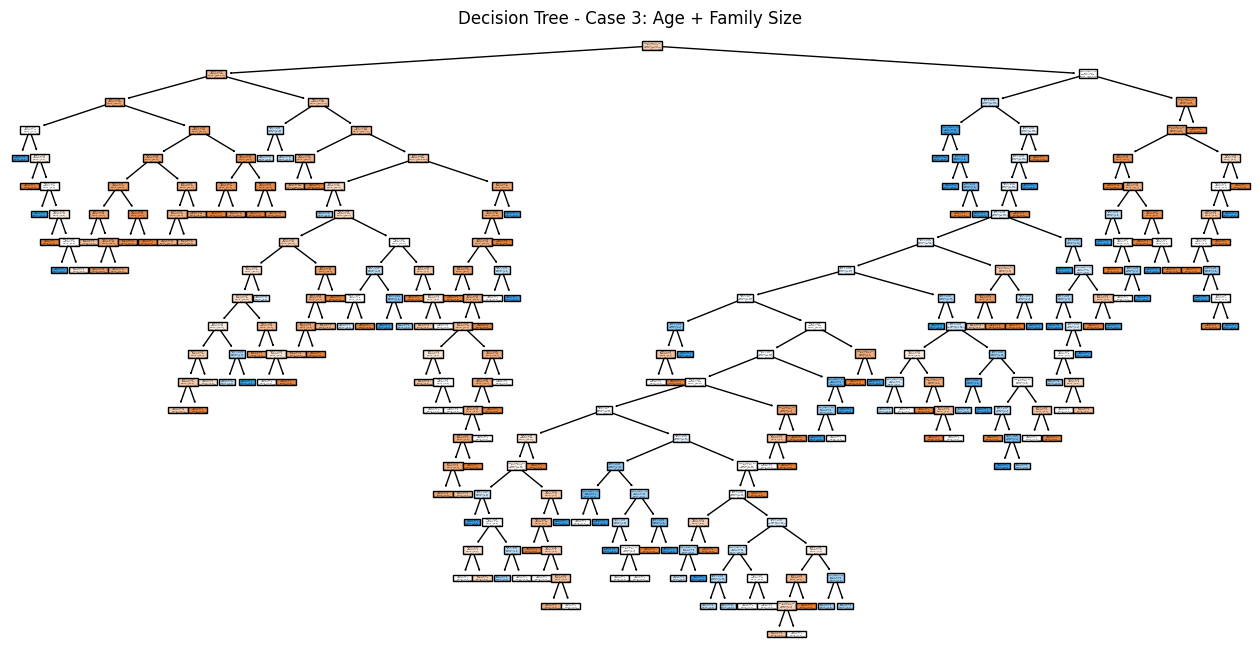

In [36]:
# -----------------------------
# Case 1: Alone
# -----------------------------
fig = plt.figure(figsize=(12, 6))
plot_tree(tree_model1,
          feature_names=X1.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True)
plt.title("Decision Tree - Case 1: Alone")
plt.show()
fig.savefig("tree_case1_alone.png")


# -----------------------------
# Case 2: Age
# -----------------------------
fig = plt.figure(figsize=(12, 6))
plot_tree(tree_model2,
          feature_names=X2.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True)
plt.title("Decision Tree - Case 2: Age")
plt.show()
fig.savefig("tree_case2_age.png")


# -----------------------------
# Case 3: Age + Family Size
# -----------------------------
fig = plt.figure(figsize=(16, 8))
plot_tree(tree_model3,
          feature_names=X3.columns,
          class_names=['Not Survived', 'Survived'],
          filled=True)
plt.title("Decision Tree - Case 3: Age + Family Size")
plt.show()
fig.savefig("tree_case3_age_family.png")


**Reflection 4:** 

1. How well did the different cases perform?
   - Case 1 (Alone) got about 63% test accuracy and caught some survivors, but overall it was limited. Case 2 (Age) had similar accuracy, but recall for survivors dropped a lot, showing that age by itself isn’t a strong predictor.
2. Are there any surprising results?
    - It was a bit surprising that adding family_size in Case 3 boosted training accuracy a lot but didn’t make a big difference in test accuracy. Another thing that stood out is how consistently the model struggled to predict survivors (Class 1), which shows how tricky imbalanced classes can be.
3. Which inputs worked better? 
    - Using both age and family_size together (Case 3) worked better than just one feature. It let the Decision Tree pick up more patterns and slightly improve recall for survivors, even though the overall test accuracy stayed moderate.


## Section 5. Compare Alternative Models (SVC, NN) <br>
Train and evaluate Support Vector Machine (SVC) and Neural Network (MLP) models on the Titanic dataset, visualize support vectors, and explore decision boundaries.

SVC Kernel: Common Types

- RBF (Radial Basis Function) – Most commonly used; handles non-linear data well (default)
- Linear – Best for linearly separable data (straight line separation)
- Polynomial – Useful when the data follows a curved pattern
- Sigmoid – Similar to a neural network activation function; less common

### 5.1 Train and Evaluate Model (SVC)

In [37]:
# -----------------------------
# Case 1: SVC using 'alone'
# -----------------------------
svc_model1 = SVC()  # default RBF kernel
svc_model1.fit(X1_train, y1_train)

y1_svc_pred = svc_model1.predict(X1_test)
print("Results for SVC on test data (Case 1 - alone):")
print(classification_report(y1_test, y1_svc_pred))


# -----------------------------
# Case 2: SVC using 'age'
# -----------------------------
svc_model2 = SVC()
svc_model2.fit(X2_train, y2_train)

y2_svc_pred = svc_model2.predict(X2_test)
print("Results for SVC on test data (Case 2 - age):")
print(classification_report(y2_test, y2_svc_pred))


# -----------------------------
# Case 3: SVC using 'age + family_size'
# -----------------------------
svc_model3 = SVC()
svc_model3.fit(X3_train, y3_train)

y3_svc_pred = svc_model3.predict(X3_test)
print("Results for SVC on test data (Case 3 - age + family_size):")
print(classification_report(y3_test, y3_svc_pred))


Results for SVC on test data (Case 1 - alone):
              precision    recall  f1-score   support

           0       0.71      0.65      0.68       110
           1       0.51      0.58      0.54        69

    accuracy                           0.63       179
   macro avg       0.61      0.62      0.61       179
weighted avg       0.64      0.63      0.63       179

Results for SVC on test data (Case 2 - age):
              precision    recall  f1-score   support

           0       0.63      0.98      0.77       110
           1       0.71      0.07      0.13        69

    accuracy                           0.63       179
   macro avg       0.67      0.53      0.45       179
weighted avg       0.66      0.63      0.52       179

Results for SVC on test data (Case 3 - age + family_size):
              precision    recall  f1-score   support

           0       0.63      0.98      0.77       110
           1       0.71      0.07      0.13        69

    accuracy                   

### 5.2 Visualize Support Vectors (1D Case 1 and 2D Case 3)

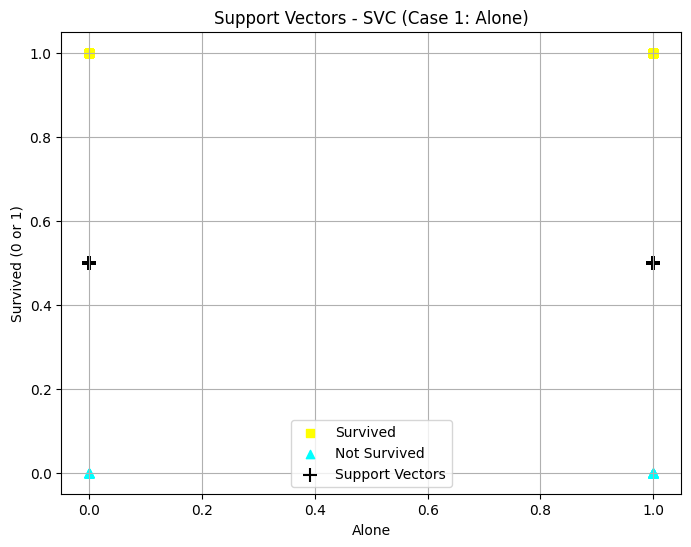

In [38]:
# -----------------------------
# Case 1: Feature = 'alone'
# -----------------------------
# Split test data into survived and not survived
survived_alone = X1_test.loc[y1_test == 1, 'alone']
not_survived_alone = X1_test.loc[y1_test == 0, 'alone']

plt.figure(figsize=(8, 6))
plt.scatter(survived_alone, y1_test.loc[y1_test == 1], c='yellow', marker='s', label='Survived')
plt.scatter(not_survived_alone, y1_test.loc[y1_test == 0], c='cyan', marker='^', label='Not Survived')

# Overlay support vectors
if hasattr(svc_model1, 'support_vectors_'):
    support_x = svc_model1.support_vectors_[:, 0]
    plt.scatter(support_x, [0.5]*len(support_x), c='black', marker='+', s=100, label='Support Vectors')

plt.xlabel('Alone')
plt.ylabel('Survived (0 or 1)')
plt.title('Support Vectors - SVC (Case 1: Alone)')
plt.legend()
plt.grid(True)
plt.show()


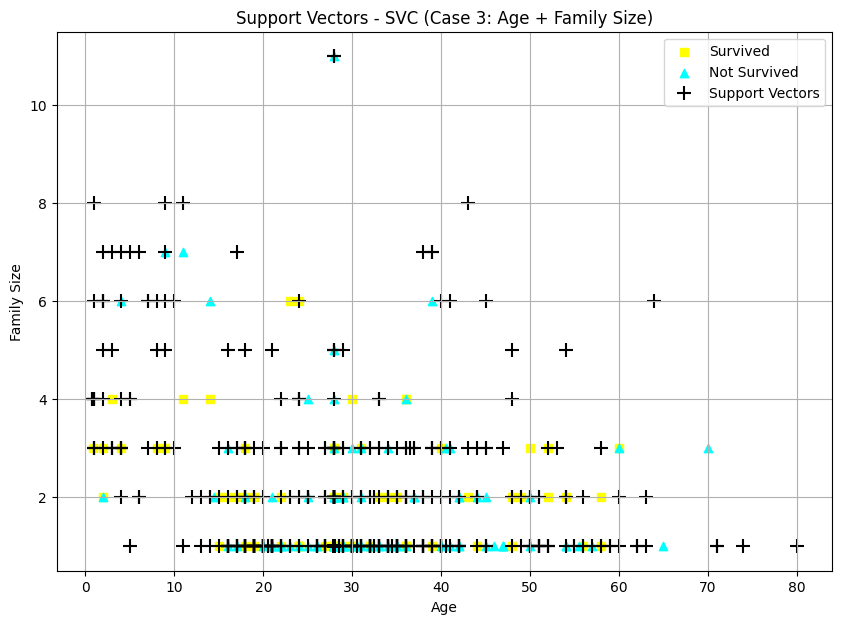

In [39]:
# -----------------------------
# Case 3: Two Inputs (age + family_size)
# -----------------------------
survived = X3_test[y3_test == 1]
not_survived = X3_test[y3_test == 0]

plt.figure(figsize=(10, 7))
plt.scatter(survived['age'], survived['family_size'], c='yellow', marker='s', label='Survived')
plt.scatter(not_survived['age'], not_survived['family_size'], c='cyan', marker='^', label='Not Survived')

# Overlay support vectors
if hasattr(svc_model3, 'support_vectors_'):
    support_vectors = svc_model3.support_vectors_
    plt.scatter(support_vectors[:, 0], support_vectors[:, 1], c='black', marker='+', s=100, label='Support Vectors')

plt.xlabel('Age')
plt.ylabel('Family Size')
plt.title('Support Vectors - SVC (Case 3: Age + Family Size)')
plt.legend()
plt.grid(True)
plt.show()


### 5.3 Train and Evaluate Model (Neural Network on Case 3)

In [40]:
# Train Neural Network on Case 3 (age + family_size)
nn_model3 = MLPClassifier(
    hidden_layer_sizes=(50, 25, 10),
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

nn_model3.fit(X3_train, y3_train)

# Predict on test data
y3_nn_pred = nn_model3.predict(X3_test)

# Print Classification report
print("Results for Neural Network on test data (Case 3 - age + family_size):")
print(classification_report(y3_test, y3_nn_pred))


Results for Neural Network on test data (Case 3 - age + family_size):
              precision    recall  f1-score   support

           0       0.67      0.90      0.77       110
           1       0.65      0.29      0.40        69

    accuracy                           0.66       179
   macro avg       0.66      0.59      0.58       179
weighted avg       0.66      0.66      0.63       179



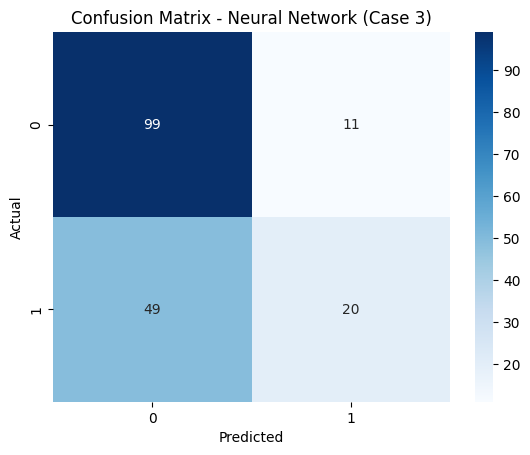

In [41]:
# Create Confusion matrix heatmap
cm_nn3 = confusion_matrix(y3_test, y3_nn_pred)

# Plot heatmap
sns.heatmap(cm_nn3, annot=True, cmap='Blues')
plt.title('Confusion Matrix - Neural Network (Case 3)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 5.4 Visualize (Neural Network on Case 3)

c:\Repos\applied-ml-beaderstadt\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


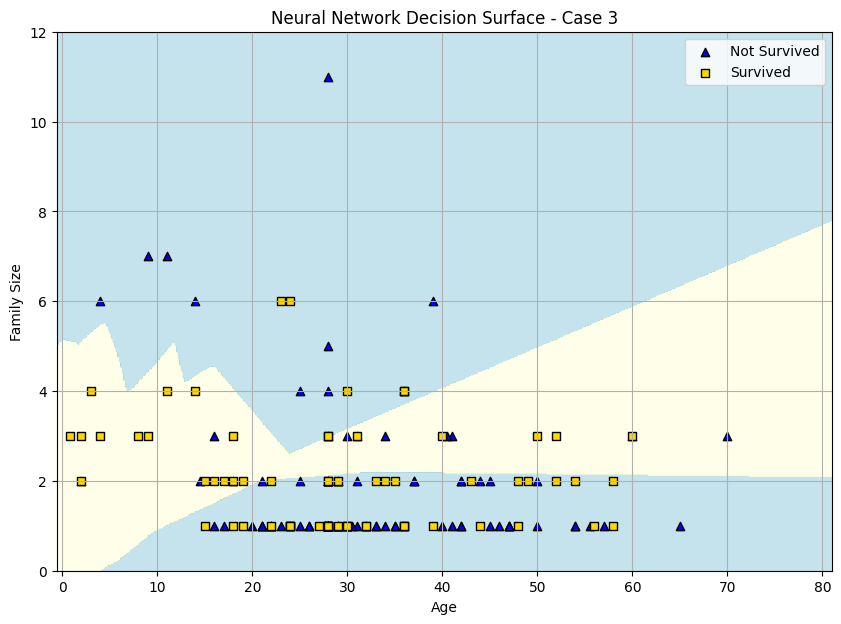

In [42]:
# Get the range of our two features - use padding to enhance appearance
padding = 1
x_min, x_max = X3['age'].min() - padding, X3['age'].max() + padding
y_min, y_max = X3['family_size'].min() - padding, X3['family_size'].max() + padding

# Create meshgrid
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# Predict on all points in the grid
Z = nn_model3.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
plt.figure(figsize=(10, 7))
cmap_background = ListedColormap(['lightblue', 'lightyellow'])
plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.7)

# Overlay actual test data points
plt.scatter(X3_test['age'][y3_test == 0],
            X3_test['family_size'][y3_test == 0],
            c='blue', marker='^', edgecolor='k', label='Not Survived')
plt.scatter(X3_test['age'][y3_test == 1],
            X3_test['family_size'][y3_test == 1],
            c='gold', marker='s', edgecolor='k', label='Survived')

plt.xlabel('Age')
plt.ylabel('Family Size')
plt.title('Neural Network Decision Surface - Case 3')
plt.legend()
plt.grid(True)
plt.show()


**Reflection 5:** 

1. How well did each of these new models/cases perform?
   - The SVC models had similar overall accuracy to the Decision Trees but had trouble catching survivors (Class 1), especially in Case 2 and Case 3. The Neural Network on Case 3 did a bit better, with higher recall for both classes and slightly better overall accuracy, showing it could pick up on more complex patterns with the two-feature input.
2. Are there any surprising results or insights?
    - It’s interesting that adding family_size really helped the Neural Network balance recall between survivors and non-survivors, while SVC and Decision Trees didn’t gain much from it. It also shows that models that can handle non-linear relationships can squeeze more predictive power out of even a small number of features.
3. Why might one model outperform the others?
    - The Neural Network probably did better because it can learn non-linear interactions between age and family_size. SVC with an RBF kernel can also model non-linear boundaries, but it struggled with the class imbalance, and Decision Trees tended to overfit the training data. The NN’s setup let it generalize better to the test data while keeping recall more balanced across the two classes.




## Section 6. Final Thoughts & Insights <br>

### Model Comparison Summary

| Case | Features          | Decision Tree (0/1)                                         | SVC (RBF) (0/1)                                              | Neural Network (MLP) (0/1)                                      | Best Model |
| ---- | ----------------- | ------------------------------------------------------------ | ------------------------------------------------------------- | ---------------------------------------------------------------- | ---------- |
| 1    | Alone             | Accuracy: 63%<br>Precision (0/1): 71% / 51%<br>Recall (0/1): 65% / 58%<br>F1-score (0/1): 68% / 54% | Accuracy: 63%<br>Precision (0/1): 71% / 51%<br>Recall (0/1): 65% / 58%<br>F1-score (0/1): 68% / 54% | N/A                                                              | Tie / Decision Tree & SVC |
| 2    | Age               | Accuracy: 61%<br>Precision (0/1): 63% / 50%<br>Recall (0/1): 89% / 17%<br>F1-score (0/1): 74% / 26% | Accuracy: 63%<br>Precision (0/1): 63% / 71%<br>Recall (0/1): 98% / 7%<br>F1-score (0/1): 77% / 13% | N/A                                                              | SVC |
| 3    | Age + Family Size | Accuracy: 59%<br>Precision (0/1): 64% / 45%<br>Recall (0/1): 75% / 33%<br>F1-score (0/1): 69% / 38% | Accuracy: 63%<br>Precision (0/1): 63% / 71%<br>Recall (0/1): 98% / 7%<br>F1-score (0/1): 77% / 13% | Accuracy: 66%<br>Precision (0/1): 67% / 65%<br>Recall (0/1): 90% / 29%<br>F1-score (0/1): 77% / 40% | Neural Network |


`note:`<br>
Class 0 = Not Survived - passengers who did not survive the Titanic sinking.  
Class 1 = Survived - passengers who survived.

### **Challenges and Next Steps**

**Challenges Faced:**  
- Some features had missing values (like `age`), so we had to drop rows for certain cases, reducing the dataset size.  
- Visualizing support vectors in 1D cases was tricky, the model operates in one dimension, but plots are 2D, so we had to use a visual trick with `[0.5]` for y-values.  
- Neural Networks required careful selection of hidden layers and iterations to prevent convergence issues and overfitting.  

**Next Steps to Gain More Insights / Explore Classification Models:**  
- Experiment with additional input features (e.g., `pclass`, `sex`, `embarked`) to see how they impact model performance.  
- Try scaling or normalizing numerical features for SVMs and Neural Networks to improve convergence and accuracy.   
- Use cross-validation instead of a single train/test split for more robust evaluation.   
- Investigate feature importance from Decision Trees to understand which inputs most influence survival predictions.  
